<a href="https://colab.research.google.com/github/Yeshwanth369/ML-DL-Projects/blob/main/Pytorch_Simple_NN_Without_Optimzers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
!pip install torch
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch


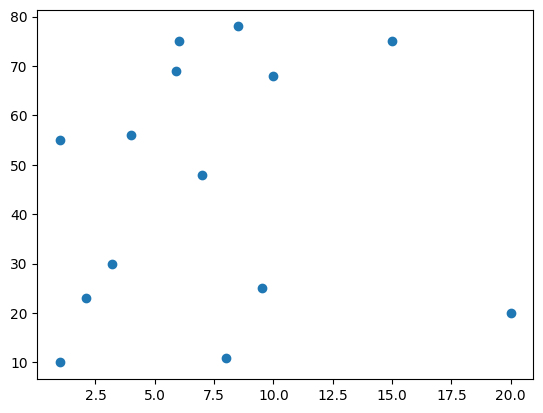

In [59]:
 x = np.array([[1,20,3.2,4,8.5,2.1,5.9,6,7,15,8,9.5,10,1]],dtype = np.float32)
 y = np.array([[10,20,30,56,78,23,69,75,48,75,11,25,68,55]],dtype = np.float32)

 plt.scatter(x,y,label = "Raw NP Data")
 plt.show()

 x_torch = torch.from_numpy(x)
 y_torch = torch.from_numpy(y)


In [60]:
x.shape

(1, 14)

In [61]:
x_torch.requires_grad #These are just input data and targets. So no need of gradients because we’re not optimizing them.
# If we are defining the Neural Net equations without torch.nn the we need to keep requires_grad = True for the weights and bias terms.

False

In [62]:
inp = 1
hidden = 5
out = 1

In [63]:
model = torch.nn.Sequential(
    torch.nn.Linear(inp,hidden),
    torch.nn.ReLU(),
    torch.nn.Linear(hidden,out)
)
loss_fn = torch.nn.MSELoss(reduction="sum") # Mean Squared Error

In [64]:
learning_rate = 1e-5
y_pred = None


# Current x_torch is (1, 14) and inp is 1. We want (14, 1) for x_torch.
# Current y_torch is (1, 14). We want (14, 1) for y_torch.
x_torch = x_torch.T # Transposing the Matrix
y_torch = y_torch.T # Transposing the Matrix

for i in range(1,501):
  y_pred = model(x_torch)

  loss = loss_fn(y_pred,y_torch)
  print("Epoch ",i,loss.item())

  model.zero_grad()
  loss.backward()

  with torch.no_grad():
    for param in model.parameters():
      param -= learning_rate*param.grad #Updating the weights

Epoch  1 40613.38671875
Epoch  2 39529.28125
Epoch  3 38602.3203125
Epoch  4 37769.71875
Epoch  5 36979.390625
Epoch  6 36192.7890625
Epoch  7 35393.625
Epoch  8 34554.71484375
Epoch  9 33662.2578125
Epoch  10 32706.7734375
Epoch  11 31683.5546875
Epoch  12 30593.330078125
Epoch  13 29442.865234375
Epoch  14 28245.29296875
Epoch  15 27019.90625
Epoch  16 25791.2578125
Epoch  17 24587.369140625
Epoch  18 23437.224609375
Epoch  19 22367.814453125
Epoch  20 21402.375
Epoch  21 20555.38671875
Epoch  22 19833.853515625
Epoch  23 19236.216796875
Epoch  24 18754.140625
Epoch  25 18374.541015625
Epoch  26 18081.83984375
Epoch  27 17859.94921875
Epoch  28 17693.775390625
Epoch  29 17570.751953125
Epoch  30 17480.591796875
Epoch  31 17412.87109375
Epoch  32 17362.251953125
Epoch  33 17324.689453125
Epoch  34 17294.09765625
Epoch  35 17268.8515625
Epoch  36 17247.291015625
Epoch  37 17229.025390625
Epoch  38 17212.373046875
Epoch  39 17196.765625
Epoch  40 17182.02734375
Epoch  41 17169.76171875


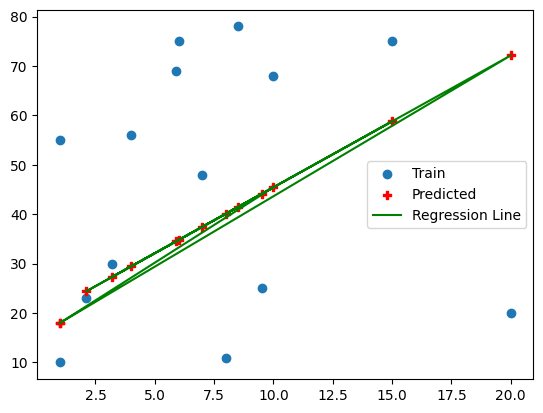

In [65]:
plt.scatter(x_torch.detach().numpy(),y_torch.detach().numpy(),label = "Train")
plt.scatter(x_torch.detach().numpy(),y_pred.detach().numpy(),color = "red", label = "Predicted",marker= "P")
plt.plot(x_torch.detach().numpy(),y_pred.detach().numpy(), color = 'green', label = "Regression Line")
plt.legend()
plt.show()

# **With Optimizer**

In [66]:
"""
optimizer_SGD = torch.nn.optim.SGD(model.parameters(), lr=0.01, )
optimizer_Adam = torch.optim.Adam(model.parameters(), lr=0.01)

for i in range(1,501):
  y_pred = model(x_torch)

  loss = loss_fn(y_pred,y_torch)
  print("Epoch ",i,loss.item())

  optimizer_adam.zero_grad()
  loss.backward()
  optimizer_adam.step()

"""

'\noptimizer_SGD = torch.nn.optim.SGD(model.parameters(), lr=0.01, )\noptimizer_Adam = torch.optim.Adam(model.parameters(), lr=0.01) \n\nfor i in range(1,501):\n  y_pred = model(x_torch)\n\n  loss = loss_fn(y_pred,y_torch)\n  print("Epoch ",i,loss.item())\n\n  optimizer_adam.zero_grad()\n  loss.backward()\n  optimizer_adam.step()\n\n'